# 基于 K-means 聚类的商场客户细分与精细化运营分析

## 项目背景

随着零售行业获客成本不断上升，统一的营销策略难以满足不同客户群体的差异化需求。商场需要根据客户的消费能力、消费活跃度和人口属性识别不同价值与行为特征的客户群体，从而优化营销资源配置，提高客户转化率和会员运营效率。

本项目基于商场客户数据，运用探索性数据分析、非参数统计检验、特征标准化和 K-means 聚类算法进行客户细分，并通过多项内部评价指标和稳定性检验评估聚类结果。在此基础上，提取不同客群的典型画像，识别高价值客户、高潜客户和低活跃客户，并制定差异化运营策略。

## 分析目标

- 检查数据完整性、唯一性、字段有效性和潜在异常值；
- 分析客户年龄、性别、年收入和消费得分的分布特征；
- 检验不同性别客户在年龄、收入和消费表现上的差异；
- 使用多项评价指标确定合理的客户群数量；
- 基于 K-means 算法建立客户细分模型；
- 通过随机种子和 Bootstrap 重抽样检验模型稳定性；
- 提取不同客群的典型画像及商业价值；
- 为不同客群制定差异化营销和会员运营策略。

## 1. 数据来源与字段说明

数据来源于 Kaggle Mall Customer Segmentation Data，是用于客户细分分析的商场客户数据集，共包含 200 条客户记录和 5 个原始字段。

| 原始字段 | 字段含义 | 数据类型 | 分析用途 |
|---|---|---|---|
| `CustomerID` | 客户唯一编号 | 整数 | 仅用于客户识别 |
| `Gender` | 客户性别 | 类别 | 用于客户结构和画像分析 |
| `Age` | 客户年龄 | 整数 | 用于人口属性分析 |
| `Annual Income (k$)` | 客户年收入，单位为千美元 | 整数 | 反映客户消费能力 |
| `Spending Score (1-100)` | 客户消费得分 | 整数 | 反映客户消费活跃度 |

其中，`CustomerID` 仅代表客户编号，不具有实际的客户属性或消费行为含义，因此不会用于相关性分析或 K-means 聚类。

In [1]:
# 数据处理
import numpy as np
import pandas as pd

# 数据可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 数据预处理
from sklearn.preprocessing import StandardScaler

# 聚类模型
from sklearn.cluster import KMeans

# 聚类评估
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

# pandas 显示设置
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# seaborn 绤图风格
sns.set_theme(style='whitegrid', palette='Set2')

# 设置图像大小和清晰度
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

# 保证模型结果可以复现
RANDOM_STATE = 42

## 2. 数据读取与字段规范化

首先导入数据处理、可视化、统计检验、特征预处理和聚类评价所需的 Python 库，并设置固定随机种子，保证分析结果具有可复现性。

读取原始数据后，对数据维度、字段名称、数据类型和随机样本进行初步检查。为了提高代码的可读性和可维护性，将原始字段统一转换为小写下划线命名格式。

In [2]:
# 读取原始数据
df = pd.read_csv('超市数据.csv')

print(f'数据集共有 {df.shape[0]} 行、{df.shape[1]} 列。')
display(df.head())

数据集共有 200 行、5 列。


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 统一字段名称，方便后续分析
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

print('修改后的字段名称：')
print(df.columns.tolist())

修改后的字段名称：
['customer_id', 'gender', 'age', 'annual_income', 'spending_score']


In [4]:
# 查看数据结构
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    int64 
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# 查看数据样本
display(df.sample(5, random_state=RANDOM_STATE))

,customer_id,gender,age,annual_income,spending_score
95,96,Male,24,60,52
15,16,Male,22,20,79
30,31,Male,60,30,4
158,159,Male,34,78,1
128,129,Male,59,71,11


In [6]:
# 查看各字段的数据类型
data_types = pd.DataFrame({
    '字段': df.columns,
    '数据类型': df.dtypes.astype(str).values
})

display(data_types)

,字段,数据类型
0,customer_id,int64
1,gender,object
2,age,int64
3,annual_income,int64
4,spending_score,int64


字段规范化后，数据包含 `customer_id`、`gender`、`age`、`annual_income` 和 `spending_score` 五个字段。

数据共有 200 行、5 列，数值字段均成功识别为整数类型，性别字段识别为类别型文本数据，未发现错误的数据类型。

## 3. 数据质量检查与清洗

在进行探索性分析和客户聚类之前，首先从缺失值、重复值、客户编号唯一性、类别有效性、数值范围和潜在异常值六个方面检查数据质量，避免错误数据对后续分析结果产生影响。

In [7]:
# 统计各字段的缺失值数量和缺失率
missing_summary = pd.DataFrame({
    '缺失值数量': df.isnull().sum(),
    '缺失率': df.isnull().mean() * 100
})

missing_summary['缺失率'] = missing_summary['缺失率'].map(
    lambda x: f'{x:.2f}%'
)

display(missing_summary)

,缺失值数量,缺失率
customer_id,0,0.00%
gender,0,0.00%
age,0,0.00%
annual_income,0,0.00%
spending_score,0,0.00%


In [8]:
# 检查完全重复的记录
full_duplicate_count = df.duplicated().sum()

# 排除客户编号后，检查客户属性完全相同的记录
profile_columns = [
    'gender',
    'age',
    'annual_income',
    'spending_score'
]

profile_duplicate_count = df.duplicated(
    subset=profile_columns
).sum()

print(f'完全重复记录数量：{full_duplicate_count}')
print(f'排除客户编号后的重复客户画像数量：{profile_duplicate_count}')

完全重复记录数量：0
排除客户编号后的重复客户画像数量：0


In [9]:
# 检查客户编号的唯一性
customer_id_unique = df['customer_id'].is_unique
customer_id_duplicate_count = df['customer_id'].duplicated().sum()

print(f'客户编号是否唯一：{customer_id_unique}')
print(f'重复客户编号数量：{customer_id_duplicate_count}')
print(
    f'客户编号范围：'
    f'{df["customer_id"].min()} - {df["customer_id"].max()}'
)

客户编号是否唯一：True
重复客户编号数量：0
客户编号范围：1 - 200


In [10]:
# 检查性别字段的类别及分布
gender_summary = (
    df['gender']
    .value_counts(dropna=False)
    .rename_axis('gender')
    .reset_index(name='count')
)

gender_summary['percentage'] = (
    gender_summary['count'] / len(df) * 100
).round(2)

display(gender_summary)

,gender,count,percentage
0,Female,112,56.00
1,Male,88,44.00


### 3.1 数据完整性与唯一性

检查结果显示：

- 五个字段的缺失值数量均为 0，缺失率均为 0%；
- 数据集中不存在完全重复的记录；
- 排除客户编号后，也不存在客户属性完全相同的重复画像；
- `customer_id` 从 1 到 200，所有客户编号均具有唯一性；
- `gender` 字段仅包含 `Female` 和 `Male` 两个有效类别；
- 女性客户共 112 人，占 56%；男性客户共 88 人，占 44%。

因此，本项目不需要进行缺失值填补、重复值删除或类别名称修正。

In [11]:
# 选择真正具有分析意义的数值变量
numeric_features = [
    'age',
    'annual_income',
    'spending_score'
]

# 查看数值变量的描述性统计
numeric_summary = df[numeric_features].describe().T

numeric_summary['range'] = (
    numeric_summary['max'] - numeric_summary['min']
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,range
age,200.00,38.85,13.97,18.00,28.75,36.00,49.00,70.00,52.00
annual_income,200.00,60.56,26.26,15.00,41.50,61.50,78.00,137.00,122.00
spending_score,200.00,50.20,25.82,1.00,34.75,50.00,73.00,99.00,98.00


In [12]:
# 根据字段业务含义设置合理性检查条件
invalid_age = df[
    (df['age'] < 18) | (df['age'] > 100)
]

invalid_income = df[
    df['annual_income'] <= 0
]

invalid_score = df[
    (df['spending_score'] < 1) |
    (df['spending_score'] > 100)
]

print(f'年龄异常记录数量：{len(invalid_age)}')
print(f'收入异常记录数量：{len(invalid_income)}')
print(f'消费得分异常记录数量：{len(invalid_score)}')

年龄异常记录数量：0
收入异常记录数量：0
消费得分异常记录数量：0


### 3.2 数值变量合理性检查

数值变量的基本范围如下：

| 变量 | 平均值 | 中位数 | 最小值 | 最大值 |
|---|---:|---:|---:|---:|
| 年龄 | 38.85 | 36.00 | 18 | 70 |
| 年收入 | 60.56 | 61.50 | 15 | 137 |
| 消费得分 | 50.20 | 50.00 | 1 | 99 |

根据字段的业务含义，本项目将客户年龄的合理范围设定为 18～100 岁，要求年收入大于 0，并要求消费得分处于 1～100 之间。

检查结果未发现违反上述业务规则的记录。三个变量均不存在负值、无效编码或明显超出业务定义的数值。

In [13]:
# 使用 IQR 方法识别数值变量中的潜在异常值
outlier_results = []

for column in numeric_features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    outlier_results.append({
        '变量': column,
        '下界': lower_bound,
        '上界': upper_bound,
        '异常值数量': outlier_count
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,变量,下界,上界,异常值数量
0,age,-1.62,79.38,0
1,annual_income,-13.25,132.75,2
2,spending_score,-22.62,130.38,0


In [14]:
# 查看年收入字段中被 IQR 识别为异常值的记录
income_q1 = df['annual_income'].quantile(0.25)
income_q3 = df['annual_income'].quantile(0.75)
income_iqr = income_q3 - income_q1

income_lower_bound = income_q1 - 1.5 * income_iqr
income_upper_bound = income_q3 + 1.5 * income_iqr

income_outliers = df[
    (df['annual_income'] < income_lower_bound) |
    (df['annual_income'] > income_upper_bound)
]

display(income_outliers)

,customer_id,gender,age,annual_income,spending_score
198,199,Male,32,137,18
199,200,Male,30,137,83


### 3.3 潜在异常值识别

使用四分位距法（IQR）检查年龄、年收入和消费得分中的潜在异常值。年龄和消费得分未发现统计异常值，年收入中有两条记录高于 IQR 上界 132.75k 美元。

两位客户的年收入均为 137k 美元，但消费得分分别为 18 和 83，分别体现了高收入低消费和高收入高消费两种不同的客户行为。其年龄、收入和消费得分仍处于合理业务范围内，也没有证据表明存在录入错误。

由于高收入客户可能是客户细分中的重要高价值或高潜力群体，本项目不将统计异常直接视为错误数据，因此保留这两条记录。

In [15]:
# 保留原始数据，并创建后续分析使用的数据副本
df_clean = df.copy()

print(f'原始数据维度：{df.shape}')
print(f'清洗后数据维度：{df_clean.shape}')
print(f'保留记录比例：{len(df_clean) / len(df) * 100:.2f}%')

原始数据维度：(200, 5)
清洗后数据维度：(200, 5)
保留记录比例：100.00%


### 3.4 数据质量检查总结

数据集整体质量较高，不存在缺失值、重复记录、重复客户编号、异常类别或违反业务规则的无效值。

IQR 方法识别出的两条高收入记录具有合理的业务含义，因此不进行删除或缩尾处理。最终保留全部 200 条客户记录，数据保留率为 100%。

后续分析将使用 `df_clean` 作为正式分析数据集，并排除不具有客户属性含义的 `customer_id`。

## 4. 探索性数据分析

本部分从客户性别结构、数值变量分布、性别分组特征和变量关系四个方面分析客户特征，为后续聚类变量选择与客户画像解释提供依据。

探索性分析主要回答以下问题：

- 数据集中的客户结构是否均衡？
- 客户年龄、年收入和消费得分呈现怎样的分布？
- 不同性别客户是否表现出明显差异？
- 年龄、收入与消费得分之间是否存在关联？
- 哪些变量组合表现出潜在的客户群体结构？

In [16]:
# 计算性别人数和占比
gender_distribution = (
    df_clean['gender']
    .value_counts()
    .rename_axis('gender')
    .reset_index(name='count')
)

gender_distribution['percentage'] = (
    gender_distribution['count'] /
    gender_distribution['count'].sum() * 100
).round(2)

display(gender_distribution)

,gender,count,percentage
0,Female,112,56.00
1,Male,88,44.00


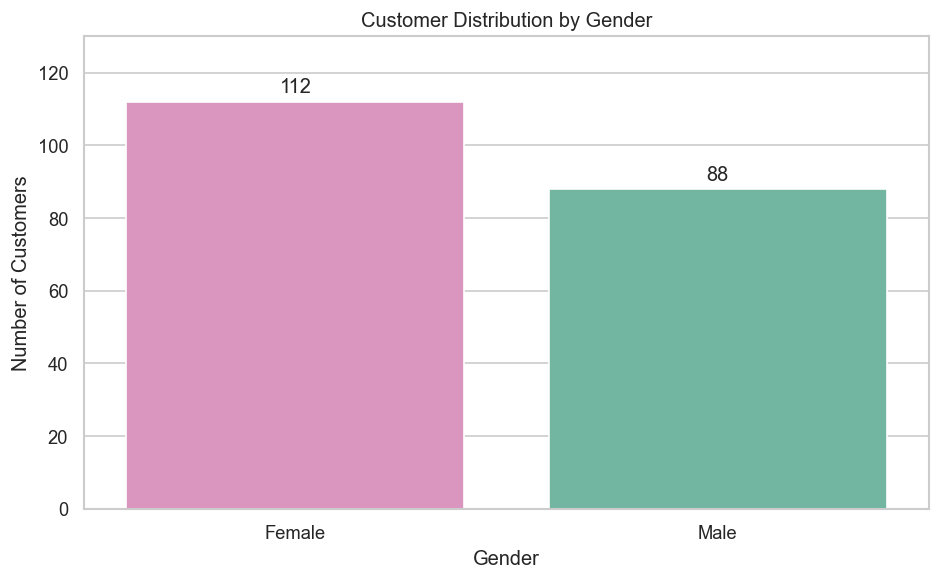

In [17]:
# 可视化客户性别结构
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_distribution,
    x='gender',
    y='count',
    hue='gender',
    palette={
        'Female': '#E78AC3',
        'Male': '#66C2A5'
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.ylim(0, 130)
plt.tight_layout()
plt.show()

### 4.1 客户性别结构

数据集中女性客户共 112 人，占全部客户的 56%；男性客户共 88 人，占 44%。

女性客户数量略高于男性客户，但两类客户均具有足够的样本量，整体性别结构不存在严重失衡，可以继续进行分组描述和统计检验。

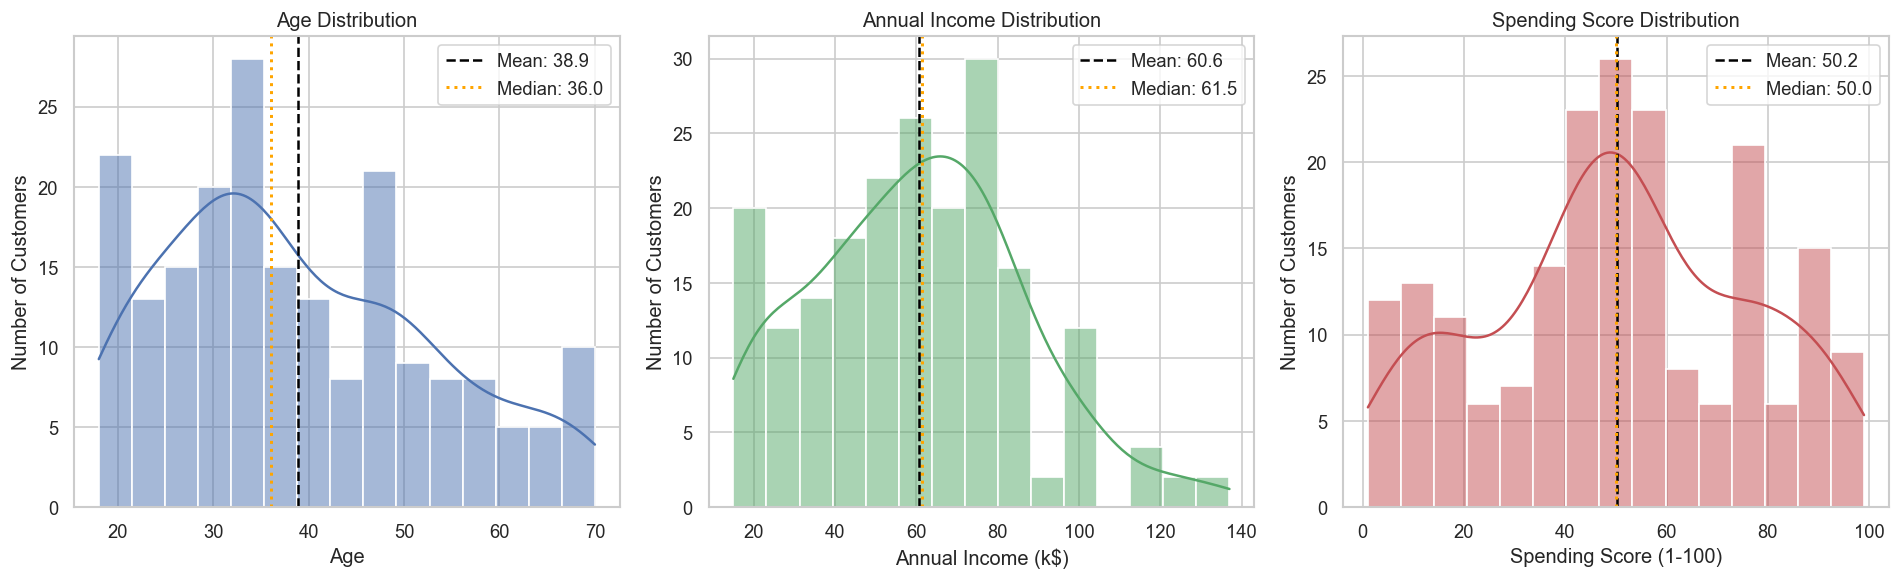

In [18]:
# 设置字段名称与图表标题
distribution_config = {
    'age': {
        'title': 'Age Distribution',
        'xlabel': 'Age',
        'color': '#4C72B0'
    },
    'annual_income': {
        'title': 'Annual Income Distribution',
        'xlabel': 'Annual Income (k$)',
        'color': '#55A868'
    },
    'spending_score': {
        'title': 'Spending Score Distribution',
        'xlabel': 'Spending Score (1-100)',
        'color': '#C44E52'
    }
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (column, config) in zip(
    axes,
    distribution_config.items()
):
    sns.histplot(
        data=df_clean,
        x=column,
        bins=15,
        kde=True,
        color=config['color'],
        edgecolor='white',
        ax=ax
    )

    ax.axvline(
        df_clean[column].mean(),
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Mean: {df_clean[column].mean():.1f}'
    )

    ax.axvline(
        df_clean[column].median(),
        color='orange',
        linestyle=':',
        linewidth=1.8,
        label=f'Median: {df_clean[column].median():.1f}'
    )

    ax.set_title(config['title'])
    ax.set_xlabel(config['xlabel'])
    ax.set_ylabel('Number of Customers')
    ax.legend()

plt.tight_layout()
plt.show()

### 4.2 数值变量分布

#### 年龄分布

客户年龄介于 18～70 岁之间，平均年龄为 38.85 岁，中位数为 36 岁。平均值略高于中位数，说明年龄分布存在一定程度的右偏。客户主要集中在中青年年龄段，同时也包含一定数量的中老年客户。

#### 年收入分布

客户年收入介于 15～137 千美元之间，平均值为 60.56k 美元，中位数为 61.50k 美元。均值与中位数较为接近，说明收入分布中心相对稳定，但不同客户之间的收入差异较大，并包含少量高收入客户。

#### 消费得分分布

消费得分介于 1～99 之间，平均值为 50.20，中位数为 50。虽然整体中心位于量表中间，但不同客户的消费得分分布范围较广，表明客户消费活跃度存在明显差异。

收入和消费得分均具有较大的离散程度，为后续识别具有不同消费能力和消费表现的客户群体提供了基础。

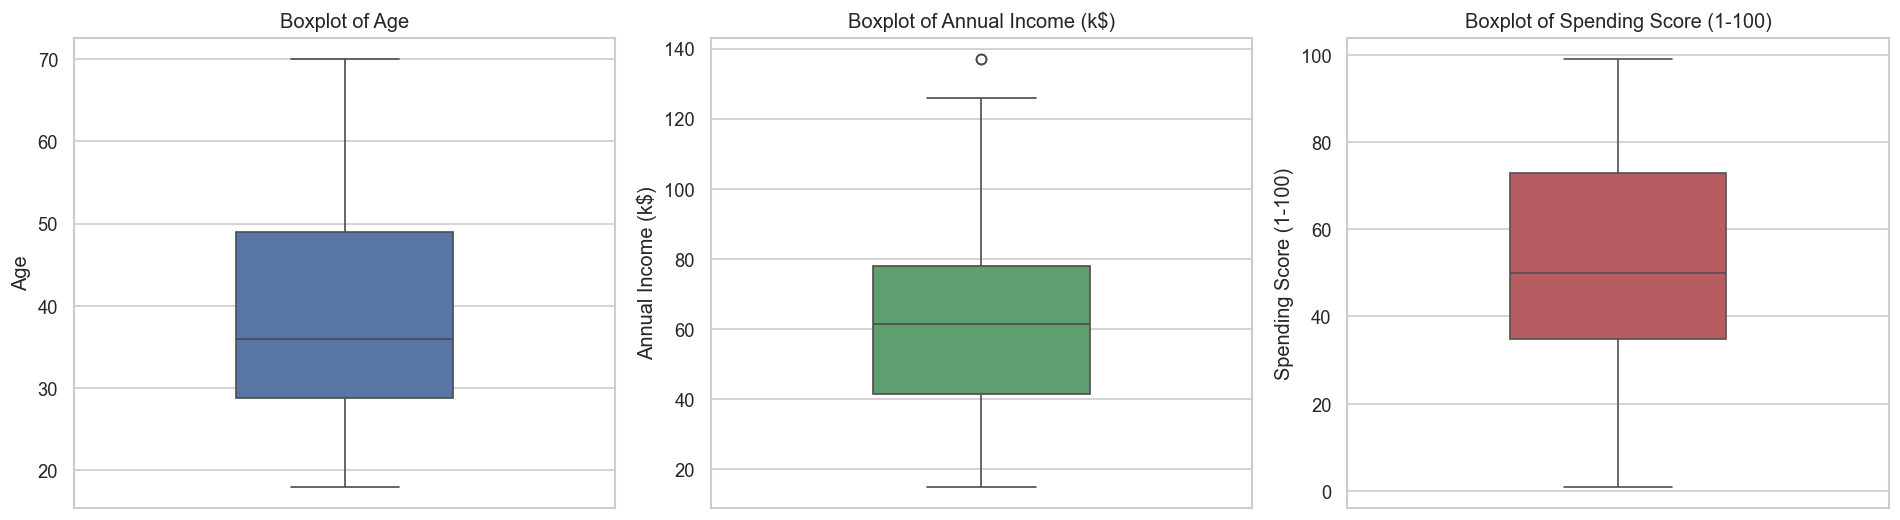

In [19]:
# 绘制数值变量箱线图
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

boxplot_config = {
    'age': ('Age', '#4C72B0'),
    'annual_income': ('Annual Income (k$)', '#55A868'),
    'spending_score': ('Spending Score (1-100)', '#C44E52')
}

for ax, (column, (label, color)) in zip(
    axes,
    boxplot_config.items()
):
    sns.boxplot(
        data=df_clean,
        y=column,
        color=color,
        width=0.4,
        ax=ax
    )

    ax.set_title(f'Boxplot of {label}')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### 4.3 数值变量异常值复核

箱线图显示，年龄和消费得分没有明显的统计异常值。年收入中存在两条位于上须之外的高值记录，与前面的 IQR 检查结果一致。

由于这两条记录仍处于合理业务范围，并分别表现出较低和较高的消费得分，因此继续保留。该结果也说明，统计异常值不一定代表错误数据，应结合业务含义决定处理方式。

In [20]:
# 按性别汇总客户特征
gender_feature_summary = (
    df_clean
    .groupby('gender')[[
        'age',
        'annual_income',
        'spending_score'
    ]]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

display(gender_feature_summary)

age                    annual_income                     \
       count  mean median   std         count  mean median   std   
gender                                                             
Female   112 38.10  35.00 12.64           112 59.25  60.00 26.01   
Male      88 39.81  37.00 15.51            88 62.23  62.50 26.64   

       spending_score                     
                count  mean median   std  
gender                                    
Female            112 51.53  50.00 24.11  
Male               88 48.51  50.00 27.90

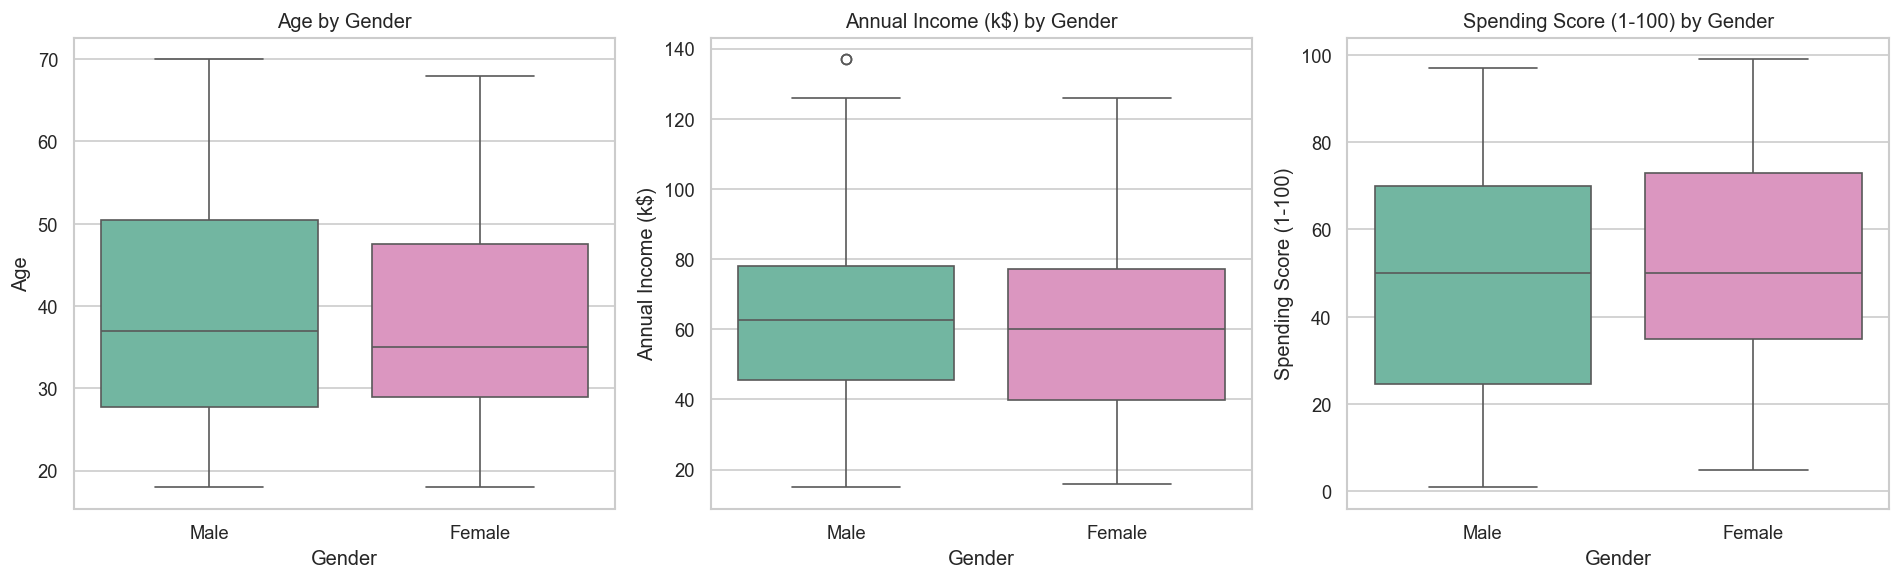

In [21]:
# 比较不同性别客户的年龄、收入和消费得分
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gender_plot_config = {
    'age': 'Age',
    'annual_income': 'Annual Income (k$)',
    'spending_score': 'Spending Score (1-100)'
}

for ax, (column, label) in zip(
    axes,
    gender_plot_config.items()
):
    sns.boxplot(
        data=df_clean,
        x='gender',
        y=column,
        hue='gender',
        palette={
            'Female': '#E78AC3',
            'Male': '#66C2A5'
        },
        legend=False,
        ax=ax
    )

    ax.set_title(f'{label} by Gender')
    ax.set_xlabel('Gender')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### 4.4 不同性别客户的特征对比

描述性统计结果显示：

| 指标 | 女性客户 | 男性客户 |
|---|---:|---:|
| 平均年龄 | 38.10 | 39.81 |
| 年龄中位数 | 35.00 | 37.00 |
| 平均年收入 | 59.25 | 62.23 |
| 年收入中位数 | 60.00 | 62.50 |
| 平均消费得分 | 51.53 | 48.51 |
| 消费得分中位数 | 50.00 | 50.00 |

男性客户的平均年龄和平均年收入略高于女性客户，女性客户的平均消费得分略高于男性客户。不过，箱线图显示两类客户在年龄、收入和消费得分上的分布存在较大重叠。

这些结果目前仅属于描述性差异，不能据此直接判断性别对客户行为具有显著影响，还需要进一步进行统计检验。

In [22]:
# 仅计算具有业务意义的数值变量之间的相关系数
correlation_matrix = df_clean[
    ['age', 'annual_income', 'spending_score']
].corr()

display(correlation_matrix.round(3))

,age,annual_income,spending_score
age,1.00,-0.01,-0.33
annual_income,-0.01,1.00,0.01
spending_score,-0.33,0.01,1.00


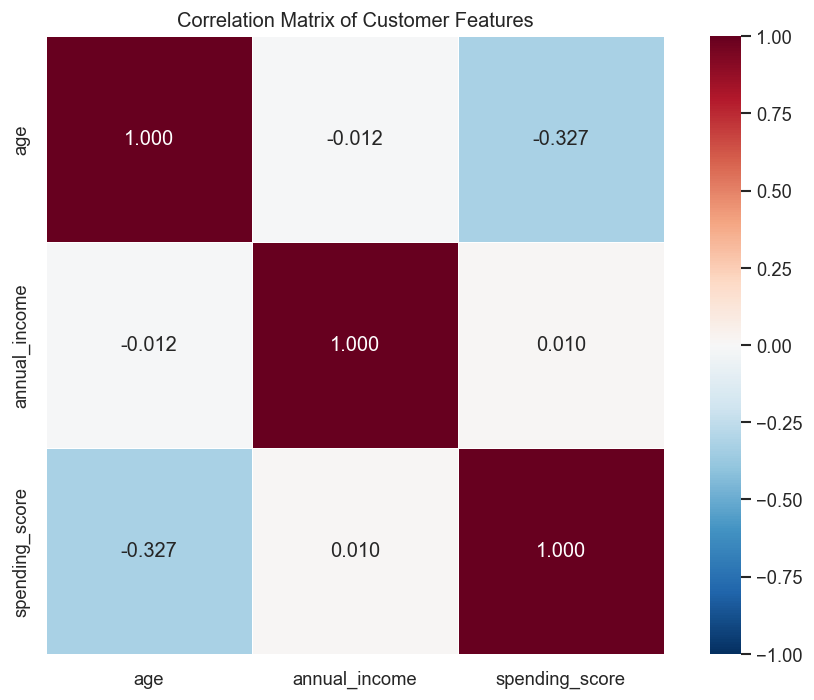

In [23]:
# 绘制相关系数热力图
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Customer Features')
plt.tight_layout()
plt.show()

### 4.5 客户特征相关性

为避免客户编号带来虚假关系，相关性分析仅使用年龄、年收入和消费得分三个具有实际业务含义的数值变量。

主要结果如下：

| 变量关系 | Pearson相关系数 | 初步解释 |
|---|---:|---|
| 年龄与年收入 | -0.012 | 几乎不存在线性关系 |
| 年龄与消费得分 | -0.327 | 存在一定程度的负相关关系 |
| 年收入与消费得分 | 0.010 | 几乎不存在线性关系 |

年龄与消费得分呈现一定的负相关关系，说明年龄较大的客户整体上倾向于具有较低的消费得分。不过，相关系数的绝对值并不高，年龄无法单独解释客户消费表现。

年收入与消费得分的整体线性相关系数接近于0，但这并不意味着二者不存在有价值的群体结构。不同收入水平中可能同时包含高消费和低消费客户，正负关系相互抵消后，整体相关系数仍可能接近于0。因此，还需要结合散点图和聚类分析进一步识别局部客户结构。

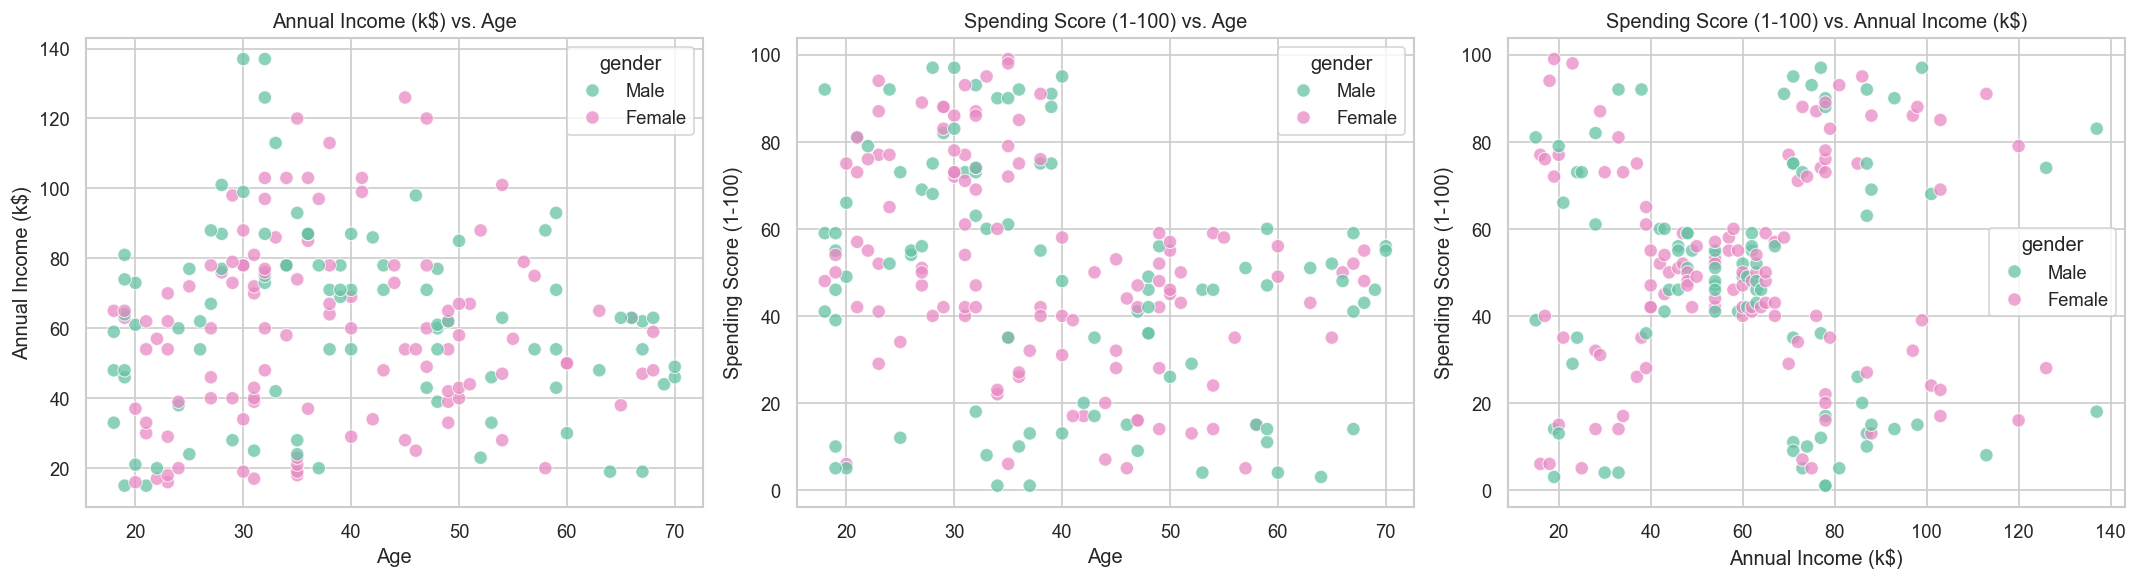

In [24]:
# 绘制三个核心变量之间的关系
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_config = [
    (
        'age',
        'annual_income',
        'Age',
        'Annual Income (k$)'
    ),
    (
        'age',
        'spending_score',
        'Age',
        'Spending Score (1-100)'
    ),
    (
        'annual_income',
        'spending_score',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    )
]

for ax, (x, y, xlabel, ylabel) in zip(
    axes,
    scatter_config
):
    sns.scatterplot(
        data=df_clean,
        x=x,
        y=y,
        hue='gender',
        palette={
            'Female': '#E78AC3',
            'Male': '#66C2A5'
        },
        alpha=0.75,
        s=65,
        ax=ax
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs. {xlabel}')

plt.tight_layout()
plt.show()

### 4.6 客户特征关系与潜在客群结构

年龄与年收入之间没有形成清晰的分组结构，不同年龄客户的收入水平较为分散。

年龄与消费得分之间呈现一定的负向关系。年轻客户中高消费得分客户相对较多，而年龄较大的客户更多集中在中低消费得分区域，这与相关系数分析结果一致。

年收入与消费得分的散点分布呈现出最清晰的局部群体结构，初步表现为：

- 高收入、高消费；
- 高收入、低消费；
- 低收入、高消费；
- 低收入、低消费；
- 中等收入、中等消费。

因此，年收入和消费得分具有较强的业务解释性和较清晰的二维群体结构，适合作为主要的客户聚类特征。

## 5. 客户性别差异的统计检验

探索性分析显示，男性和女性客户在平均年龄、平均收入和平均消费得分上存在小幅差异。为了判断这些差异是否具有统计意义，本项目进一步使用双侧 Mann–Whitney U 检验比较两组客户的变量分布。

选择该方法的原因是，Mann–Whitney U 检验属于非参数检验，不要求变量严格服从正态分布，适合比较两个相互独立客户群体的数值分布。

本项目将显著性水平设定为：

$$
\alpha = 0.05
$$

对于每个变量：

- 原假设 $H_0$：男性和女性客户的变量分布不存在显著差异；
- 备择假设 $H_1$：男性和女性客户的变量分布存在显著差异。

当 p 值小于 0.05 时拒绝原假设；当 p 值不小于 0.05 时，没有足够证据拒绝原假设。

除 p 值外，本项目同时计算 rank-biserial correlation 衡量差异的效应大小。该指标的绝对值越接近0，表示两组之间的实际差异越小。

In [25]:
# 统计检验
from scipy.stats import mannwhitneyu

# 分别提取女性和男性客户数据
female_customers = df_clean[
    df_clean['gender'] == 'Female'
]

male_customers = df_clean[
    df_clean['gender'] == 'Male'
]

test_features = [
    'age',
    'annual_income',
    'spending_score'
]

test_results = []

for feature in test_features:
    female_values = female_customers[feature]
    male_values = male_customers[feature]

    u_statistic, p_value = mannwhitneyu(
        female_values,
        male_values,
        alternative='two-sided'
    )

    # Rank-biserial correlation，用于衡量效应大小
    rank_biserial = (
        2 * u_statistic /
        (len(female_values) * len(male_values)) - 1
    )

    test_results.append({
        'feature': feature,
        'female_median': female_values.median(),
        'male_median': male_values.median(),
        'u_statistic': u_statistic,
        'p_value': p_value,
        'rank_biserial': rank_biserial,
        'significant_at_0.05': p_value < 0.05
    })

gender_test_results = pd.DataFrame(test_results)

display(
    gender_test_results.round({
        'female_median': 2,
        'male_median': 2,
        'u_statistic': 2,
        'p_value': 4,
        'rank_biserial': 4
    })
)

,feature,female_median,male_median,u_statistic,p_value,rank_biserial,significant_at_0.05
0,age,35.00,37.00,4728.50,0.62,-0.04,False
1,annual_income,60.00,62.50,4596.00,0.41,-0.07,False
2,spending_score,50.00,50.00,5158.50,0.57,0.05,False


### 5.1 性别差异检验结果

Mann–Whitney U检验结果如下：

| 检验变量 | p值 | Rank-biserial correlation | 是否显著 |
|---|---:|---:|---|
| 年龄 | 0.6242 | -0.0405 | 否 |
| 年收入 | 0.4144 | -0.0674 | 否 |
| 消费得分 | 0.5713 | 0.0468 | 否 |

三个变量的 p 值均大于0.05，因此没有足够证据拒绝原假设。当前样本没有显示男性和女性客户在年龄、年收入或消费得分的分布上存在统计显著差异。

同时，三个变量的 rank-biserial correlation 绝对值均小于0.1，表明两类客户之间的实际差异也较小。

因此，本项目不将性别作为核心聚类特征，而是在聚类完成后将其作为补充画像变量，用于描述不同客群的性别构成。

## 6. 聚类特征选择

本项目选择 `annual_income` 和 `spending_score` 作为核心聚类特征。

选择这两个变量的原因如下：

1. **业务含义明确**  
   年收入反映客户的消费能力和潜在支付能力，消费得分反映客户当前的消费活跃度和消费表现。二者分别代表“消费能力”和“消费行为”。

2. **具有互补的信息价值**  
   年收入与消费得分的相关系数约为0.010，说明两者之间不存在明显的线性关系，能够从不同维度描述客户。

3. **呈现清晰的局部群体结构**  
   散点图中初步出现高收入高消费、高收入低消费、低收入高消费、低收入低消费以及中等收入中等消费等潜在客户群体。

4. **便于模型解释与可视化**  
   使用两个核心特征可以直接在二维平面中展示聚类结果，有助于将模型输出转化为可理解、可执行的客户运营策略。

`age` 不直接参与主要聚类，而是在聚类完成后用于解释不同客群的人口属性。`gender` 的统计检验未发现显著差异，因此同样作为补充画像变量，而不是核心聚类特征。

In [26]:
# 选择核心聚类特征
clustering_features = [
    'annual_income',
    'spending_score'
]

X = df_clean[clustering_features].copy()

print('聚类特征：')
print(clustering_features)

display(X.head())

聚类特征：
['annual_income', 'spending_score']


,annual_income,spending_score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 7. 聚类特征标准化

K-means通过计算样本与聚类中心之间的欧氏距离划分客户。其基本目标是最小化所有样本到所属聚类中心的平方距离之和：

$$
\underset{C_1,\ldots,C_K}{\operatorname{minimize}}
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
\left\|x_i-\mu_k\right\|^2
$$

其中，$C_k$ 表示第 $k$ 个客户群体，$\mu_k$ 表示该群体的聚类中心。

由于欧氏距离会受到变量计量单位和取值尺度的影响，取值范围较大的变量可能在距离计算中占据更高权重。年收入和消费得分具有不同的业务含义与计量单位，因此在建模前使用 `StandardScaler` 进行标准化：

$$
z = \frac{x-\mu}{\sigma}
$$

其中，$\mu$ 为变量均值，$\sigma$ 为变量标准差。标准化后，每个变量的均值接近0、标准差接近1，使两个特征在距离计算中具有相对平等的影响。

In [27]:
# 创建标准化工具
scaler = StandardScaler()

# 对聚类特征进行标准化
X_scaled = scaler.fit_transform(X)

# 转换成 DataFrame，方便查看
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[
        'annual_income_scaled',
        'spending_score_scaled'
    ],
    index=df_clean.index
)

display(X_scaled_df.head())

,annual_income_scaled,spending_score_scaled
0,-1.74,-0.43
1,-1.74,1.20
2,-1.70,-1.72
3,-1.70,1.04
4,-1.66,-0.40


In [28]:
# 检查标准化后的均值和标准差
scaling_check = pd.DataFrame({
    'mean': X_scaled_df.mean(),
    'std': X_scaled_df.std(ddof=0)
})

display(scaling_check.round(4))

,mean,std
annual_income_scaled,-0.00,1.00
spending_score_scaled,-0.00,1.00


### 7.1 标准化结果

标准化结果显示，年收入和消费得分的均值均接近0，标准差均等于1，说明特征标准化处理正确。

后续最佳K值选择、模型训练、模型评价和稳定性检验均使用标准化后的 `X_scaled` 数据。聚类完成后，再通过逆标准化将聚类中心还原为原始业务单位，以便解释模型结果。

## 8. 最佳聚类数量选择

客户群数量 $K$ 是K-means模型中需要预先确定的重要参数。若K值过小，不同类型的客户可能被合并；若K值过大，则可能产生规模过小、难以解释和难以执行的细分客群。

为了减少仅依赖肘部法进行主观判断的局限，本项目对K=2～10的模型进行比较，并综合使用以下四项指标：

### 8.1. Inertia

Inertia表示所有样本到所属聚类中心的平方距离总和，数值越低表示类内样本越紧密。但Inertia会随着K值增加而自然下降，因此主要观察曲线下降速度是否出现明显转折，而不是简单选择Inertia最低的模型。

### 8.2. Silhouette Score

轮廓系数同时衡量类内紧密程度和类间分离程度，取值范围为-1～1，数值越高表示聚类效果越好。

### 8.3. Calinski-Harabasz Score

该指标比较类间离散程度与类内离散程度，数值越高通常表示不同群体之间分离越明显。

### 8.4. Davies-Bouldin Score

该指标衡量不同聚类之间的平均相似程度，数值越低表示类内更紧密、类间更分离。

最终K值将综合模型评价指标、客群可解释性和运营可执行性确定。

In [29]:
# 比较不同 K 值下的聚类评价指标
k_values = range(2, 11)
evaluation_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(X_scaled)

    evaluation_results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(
            X_scaled,
            labels
        ),
        'calinski_harabasz_score':
            calinski_harabasz_score(
                X_scaled,
                labels
            ),
        'davies_bouldin_score':
            davies_bouldin_score(
                X_scaled,
                labels
            )
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df.round(4))

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,269.69,0.32,95.67,1.27
1,3,157.70,0.47,151.34,0.72
2,4,108.92,0.49,174.60,0.71
3,5,65.57,0.55,248.65,0.57
4,6,55.06,0.54,243.09,0.65
5,7,44.86,0.53,254.62,0.71
6,8,37.15,0.46,267.91,0.76
7,9,32.36,0.46,271.24,0.75
8,10,29.08,0.45,269.31,0.75


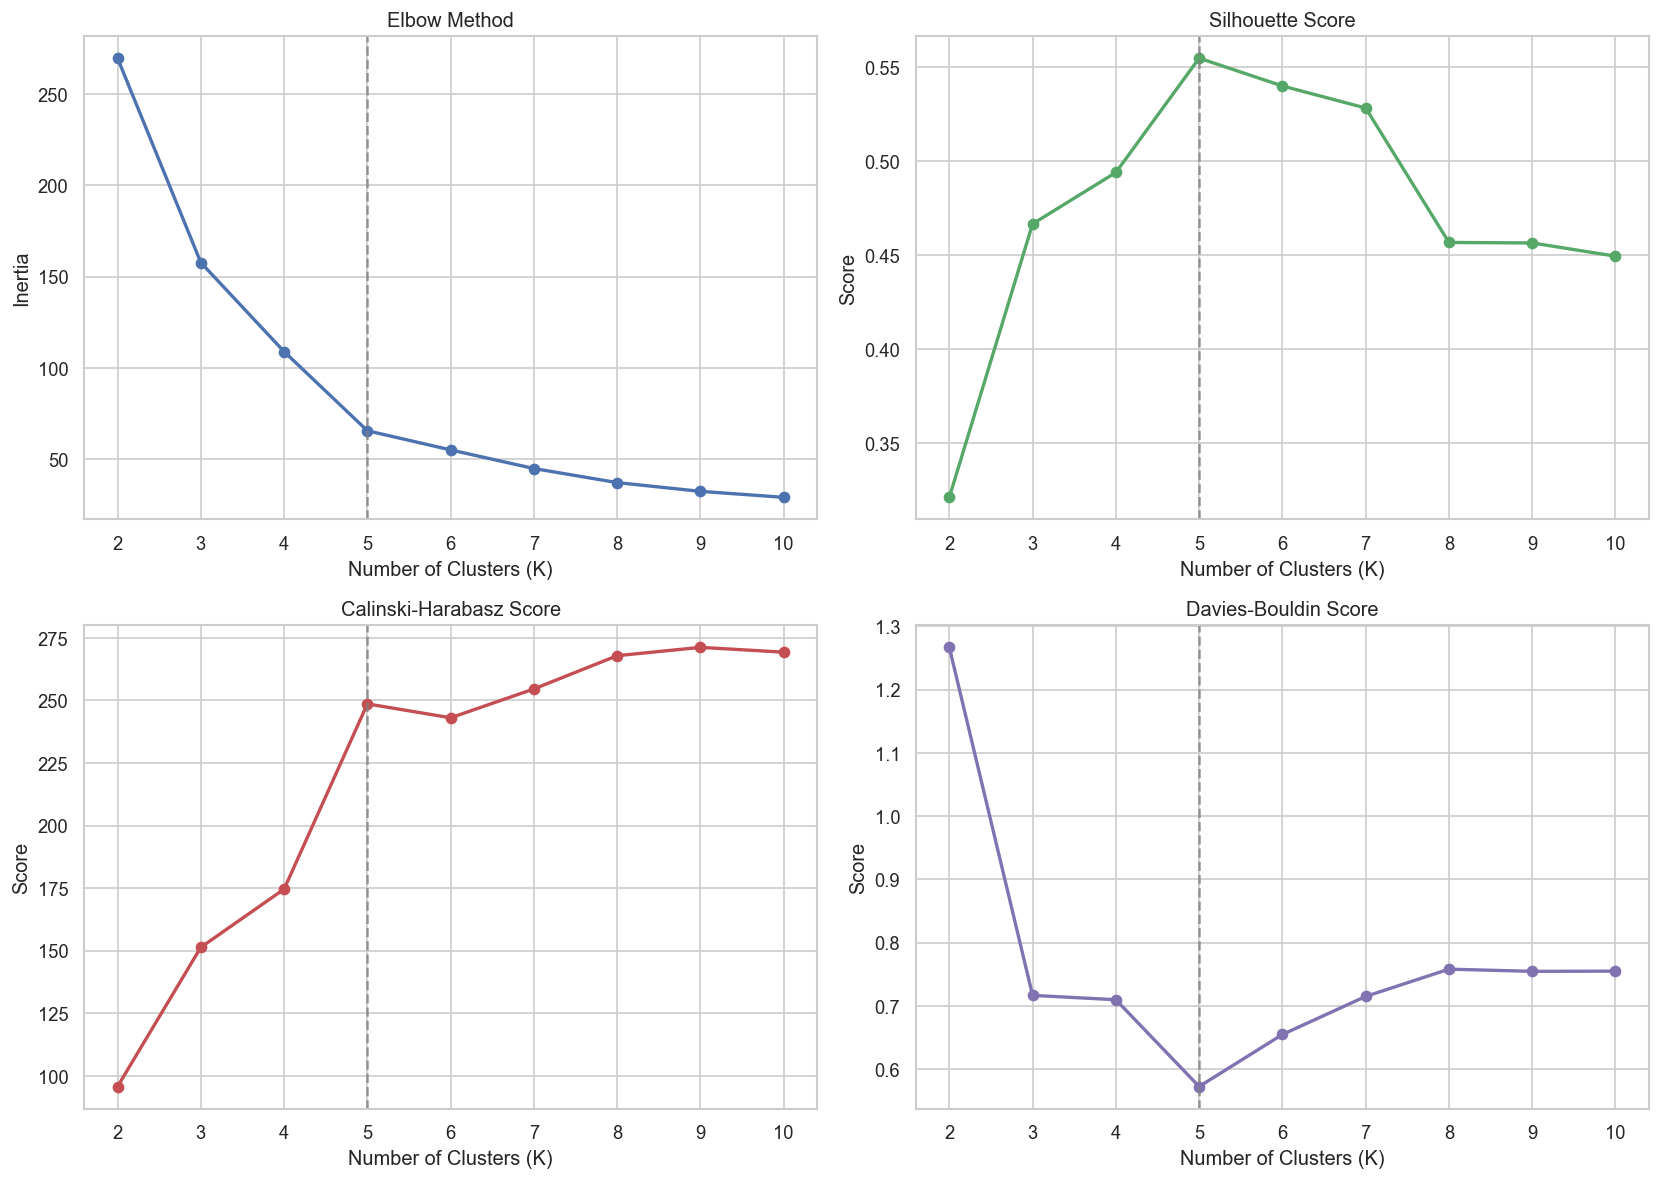

In [30]:
# 可视化不同 K 值的聚类评价指标
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Inertia
axes[0, 0].plot(
    evaluation_df['k'],
    evaluation_df['inertia'],
    marker='o',
    linewidth=2,
    color='#4C72B0'
)
axes[0, 0].set_title('Elbow Method')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_xticks(evaluation_df['k'])

# Silhouette Score
axes[0, 1].plot(
    evaluation_df['k'],
    evaluation_df['silhouette_score'],
    marker='o',
    linewidth=2,
    color='#55A868'
)
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(evaluation_df['k'])

# Calinski-Harabasz Score
axes[1, 0].plot(
    evaluation_df['k'],
    evaluation_df['calinski_harabasz_score'],
    marker='o',
    linewidth=2,
    color='#C44E52'
)
axes[1, 0].set_title('Calinski-Harabasz Score')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_xticks(evaluation_df['k'])

# Davies-Bouldin Score
axes[1, 1].plot(
    evaluation_df['k'],
    evaluation_df['davies_bouldin_score'],
    marker='o',
    linewidth=2,
    color='#8172B2'
)
axes[1, 1].set_title('Davies-Bouldin Score')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticks(evaluation_df['k'])

# 标记 K=5
for ax in axes.flat:
    ax.axvline(
        x=5,
        color='gray',
        linestyle='--',
        alpha=0.8
    )

plt.tight_layout()
plt.show()

### 8.5 最佳K值选择结果

不同K值的评价结果显示：

- Inertia曲线在K=5附近出现较为明显的转折；
- K=5的轮廓系数约为0.5547，是所有候选模型中的最高值；
- K=5的Davies-Bouldin Score约为0.5722，是所有候选模型中的最低值；
- K=5的Calinski-Harabasz Score约为248.65，处于较高水平；
- K=5能够形成具有明确业务含义的五类客户结构。

虽然Calinski-Harabasz Score在部分更大的K值下继续上升，但过多的客户群体会增加业务理解、营销资源配置和运营执行的复杂度。

综合模型质量、客群可解释性与营销可执行性，本项目最终选择：

$$
K = 5
$$

## 9. 最终K-means客户细分模型

根据最佳K值评价结果，本项目使用K=5建立最终客户细分模型。

模型采用以下设置：

- 聚类数量：`n_clusters=5`
- 初始化方式：`k-means++`
- 初始中心搜索次数：`n_init=50`
- 最大迭代次数：`max_iter=500`
- 固定随机种子：`random_state=42`

K-means++通过优化初始聚类中心的选择，降低初始中心过于接近的风险；重复50次初始中心搜索可以进一步降低模型陷入较差局部最优解的可能性。

In [31]:
# 建立最终 K-means 模型
optimal_k = 5

final_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE
)

# 训练模型并获得每位客户的聚类标签
cluster_labels = final_kmeans.fit_predict(X_scaled)

# 将聚类标签添加到客户数据中
df_clustered = df_clean.copy()
df_clustered['cluster'] = cluster_labels

print('模型训练完成。')
print(f'聚类数量：{final_kmeans.n_clusters}')
print(f'模型迭代次数：{final_kmeans.n_iter_}')
print(f'最终 Inertia：{final_kmeans.inertia_:.2f}')

display(df_clustered.head())

模型训练完成。
聚类数量：5
模型迭代次数：4
最终 Inertia：65.57


,customer_id,gender,age,annual_income,spending_score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 9.1 模型训练结果

最终模型经过4次迭代后收敛，Inertia约为65.57。模型为每位客户分配了一个0～4的聚类编号，并完整保留了全部200条客户记录。

需要注意的是，K-means生成的聚类编号本身不具有大小、等级或固定业务含义。Cluster 0并不天然优于Cluster 1，客群含义必须根据还原后的聚类中心和客户特征进行解释。

In [32]:
# 统计各个聚类的客户数量和占比
cluster_size = (
    df_clustered['cluster']
    .value_counts()
    .sort_index()
    .rename_axis('cluster')
    .reset_index(name='customer_count')
)

cluster_size['percentage'] = (
    cluster_size['customer_count'] /
    len(df_clustered) * 100
)

display(
    cluster_size.style.format({
        'customer_count': '{:.0f}',
        'percentage': '{:.2f}%'
    })
)

,cluster,customer_count,percentage
0,0,81,40.50%
1,1,39,19.50%
2,2,22,11.00%
3,3,35,17.50%
4,4,23,11.50%


In [33]:
# 获取标准化空间中的聚类中心
scaled_cluster_centers = final_kmeans.cluster_centers_

# 将聚类中心还原为原始业务单位
original_cluster_centers = scaler.inverse_transform(
    scaled_cluster_centers
)

cluster_centers_df = pd.DataFrame(
    original_cluster_centers,
    columns=[
        'annual_income_center',
        'spending_score_center'
    ]
)

cluster_centers_df.index.name = 'cluster'

display(
    cluster_centers_df.style.format({
        'annual_income_center': '{:.2f}',
        'spending_score_center': '{:.2f}'
    })
)

,annual_income_center,spending_score_center
cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


### 9.2 聚类中心解释

将标准化空间中的聚类中心逆转换为原始业务单位后，五个聚类中心如下：

| 聚类编号 | 年收入中心（千美元） | 消费得分中心 | 初步特征 |
|---:|---:|---:|---|
| 0 | 55.30 | 49.52 | 中等收入、中等消费 |
| 1 | 86.54 | 82.13 | 高收入、高消费 |
| 2 | 25.73 | 79.36 | 低收入、高消费 |
| 3 | 88.20 | 17.11 | 高收入、低消费 |
| 4 | 26.30 | 20.91 | 低收入、低消费 |

五个聚类中心在收入和消费得分两个维度上呈现出清晰差异。其中，高收入高消费客户是当前商业价值最高的群体；高收入低消费客户虽然当前活跃度较低，但具有较强支付能力和较大的激活潜力。

## 10. 客群命名与客户画像

为了提高模型结果的业务可解释性，根据聚类中心以及各客群的年龄、收入和消费得分特征，为五个聚类赋予业务名称：

| 聚类编号 | 客群名称 | 命名依据 |
|---:|---|---|
| 0 | 普通消费客群 | 客群规模最大，收入与消费表现接近整体平均水平 |
| 1 | 高价值客群 | 收入和消费得分均明显较高 |
| 2 | 年轻活跃客群 | 收入较低、消费得分较高，且平均年龄最低 |
| 3 | 高潜力客群 | 收入水平最高，但消费得分明显偏低 |
| 4 | 低消费客群 | 收入和消费得分均较低 |

“年轻活跃客群”中的年龄特征不是直接参与聚类的变量，而是在聚类完成后，通过比较各客群的平均年龄得到的补充画像特征。

In [34]:
# 根据聚类中心和客户特征为不同客群命名
segment_name_map = {
    0: '普通消费客群',
    1: '高价值客群',
    2: '年轻活跃客群',
    3: '高潜力客群',
    4: '低消费客群'
}

# 英文名称用于图表，避免中文字体显示问题
segment_code_map = {
    0: 'Mainstream',
    1: 'High-Value',
    2: 'Young Active',
    3: 'High-Potential',
    4: 'Low-Spending'
}

df_clustered['segment_name'] = (
    df_clustered['cluster'].map(segment_name_map)
)

df_clustered['segment_code'] = (
    df_clustered['cluster'].map(segment_code_map)
)

display(
    df_clustered[[
        'customer_id',
        'gender',
        'age',
        'annual_income',
        'spending_score',
        'cluster',
        'segment_name'
    ]].head(10)
)

,customer_id,gender,age,annual_income,spending_score,cluster,segment_name
0,1,Male,19,15,39,4,低消费客群
1,2,Male,21,15,81,2,年轻活跃客群
2,3,Female,20,16,6,4,低消费客群
3,4,Female,23,16,77,2,年轻活跃客群
4,5,Female,31,17,40,4,低消费客群
5,6,Female,22,17,76,2,年轻活跃客群
6,7,Female,35,18,6,4,低消费客群
7,8,Female,23,18,94,2,年轻活跃客群
8,9,Male,64,19,3,4,低消费客群
9,10,Female,30,19,72,2,年轻活跃客群


In [35]:
# 按客群汇总客户画像
segment_profile = (
    df_clustered
    .groupby([
        'cluster',
        'segment_name'
    ])
    .agg(
        customer_count=(
            'customer_id',
            'count'
        ),
        average_age=(
            'age',
            'mean'
        ),
        median_age=(
            'age',
            'median'
        ),
        average_income=(
            'annual_income',
            'mean'
        ),
        median_income=(
            'annual_income',
            'median'
        ),
        average_spending_score=(
            'spending_score',
            'mean'
        ),
        median_spending_score=(
            'spending_score',
            'median'
        ),
        female_percentage=(
            'gender',
            lambda x: (x == 'Female').mean() * 100
        )
    )
    .reset_index()
)

segment_profile['customer_percentage'] = (
    segment_profile['customer_count'] /
    len(df_clustered) * 100
)

segment_profile = segment_profile[[
    'cluster',
    'segment_name',
    'customer_count',
    'customer_percentage',
    'average_age',
    'median_age',
    'average_income',
    'median_income',
    'average_spending_score',
    'median_spending_score',
    'female_percentage'
]]

display(
    segment_profile.style.format({
        'customer_count': '{:.0f}',
        'customer_percentage': '{:.2f}%',
        'average_age': '{:.2f}',
        'median_age': '{:.2f}',
        'average_income': '{:.2f}',
        'median_income': '{:.2f}',
        'average_spending_score': '{:.2f}',
        'median_spending_score': '{:.2f}',
        'female_percentage': '{:.2f}%'
    })
)

,cluster,segment_name,customer_count,customer_percentage,average_age,median_age,average_income,median_income,average_spending_score,median_spending_score,female_percentage
0,0,普通消费客群,81,40.50%,42.72,46.00,55.30,54.00,49.52,50.00,59.26%
1,1,高价值客群,39,19.50%,32.69,32.00,86.54,79.00,82.13,83.00,53.85%
2,2,年轻活跃客群,22,11.00%,25.27,23.50,25.73,24.50,79.36,77.00,59.09%
3,3,高潜力客群,35,17.50%,41.11,42.00,88.20,85.00,17.11,16.00,45.71%
4,4,低消费客群,23,11.50%,45.22,46.00,26.30,25.00,20.91,17.00,60.87%


### 10.1 五类客户画像

#### 1. 普通消费客群

该客群共81人，占全部客户的40.50%，是规模最大的客户群。平均年龄为42.72岁，平均年收入为55.30千美元，平均消费得分为49.52。收入和消费表现均接近整体平均水平，是商场维持日常经营的基础客户群。

#### 2. 高价值客群

该客群共39人，占19.50%。平均年龄为32.69岁，平均年收入为86.54千美元，平均消费得分为82.13。同时具有较强消费能力和较高消费活跃度，是当前商业价值最高的客户群。

#### 3. 年轻活跃客群

该客群共22人，占11.00%。平均年龄为25.27岁，是五类客户中最年轻的群体。虽然平均年收入仅为25.73千美元，但平均消费得分达到79.36，表现出较强的消费意愿和活跃度。

#### 4. 高潜力客群

该客群共35人，占17.50%。平均年龄为41.11岁，平均年收入达到88.20千美元，是五类客户中收入最高的群体，但平均消费得分仅为17.11。该客群具有较强消费能力，但当前消费活跃度不足，具有较大的营销转化潜力。

#### 5. 低消费客群

该客群共23人，占11.50%。平均年龄为45.22岁，平均年收入为26.30千美元，平均消费得分为20.91。当前消费能力和消费活跃度均相对有限。

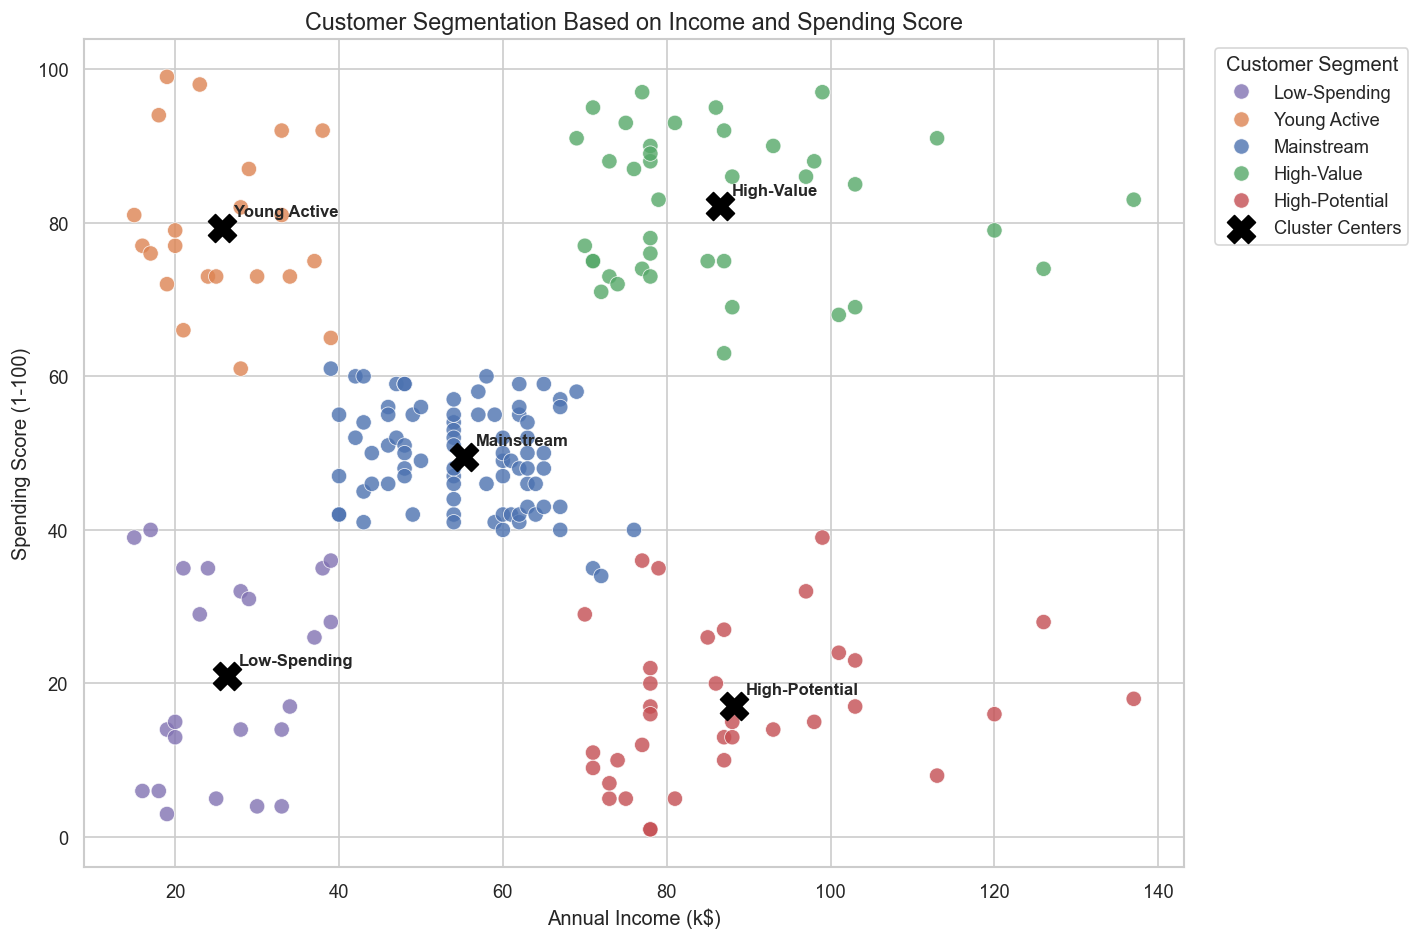

In [36]:
# 设置客群颜色
segment_colors = {
    'Mainstream': '#4C72B0',
    'High-Value': '#55A868',
    'Young Active': '#DD8452',
    'High-Potential': '#C44E52',
    'Low-Spending': '#8172B2'
}

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_clustered,
    x='annual_income',
    y='spending_score',
    hue='segment_code',
    palette=segment_colors,
    s=85,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5
)

# 绘制聚类中心
plt.scatter(
    original_cluster_centers[:, 0],
    original_cluster_centers[:, 1],
    s=280,
    c='black',
    marker='X',
    label='Cluster Centers'
)

# 给聚类中心添加客群标签
for cluster_id, row in cluster_centers_df.iterrows():
    segment_code = segment_code_map[cluster_id]

    plt.annotate(
        segment_code,
        (
            row['annual_income_center'],
            row['spending_score_center']
        ),
        xytext=(7, 7),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Customer Segmentation Based on Income and Spending Score',
    fontsize=14
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(
    title='Customer Segment',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### 10.2 客户细分结果可视化

最终散点图显示，五类客户在年收入和消费得分两个维度上形成了较为清晰的群体结构：

- 高价值客群位于右上区域，表现为高收入、高消费；
- 高潜力客群位于右下区域，表现为高收入、低消费；
- 年轻活跃客群位于左上区域，表现为低收入、高消费；
- 低消费客群位于左下区域，表现为低收入、低消费；
- 普通消费客群集中在图形中央，收入和消费表现相对均衡。

黑色“X”代表各客群在原始业务单位下的聚类中心。不同客群之间整体分离较为明显，普通消费客群规模最大并位于数据中心区域。

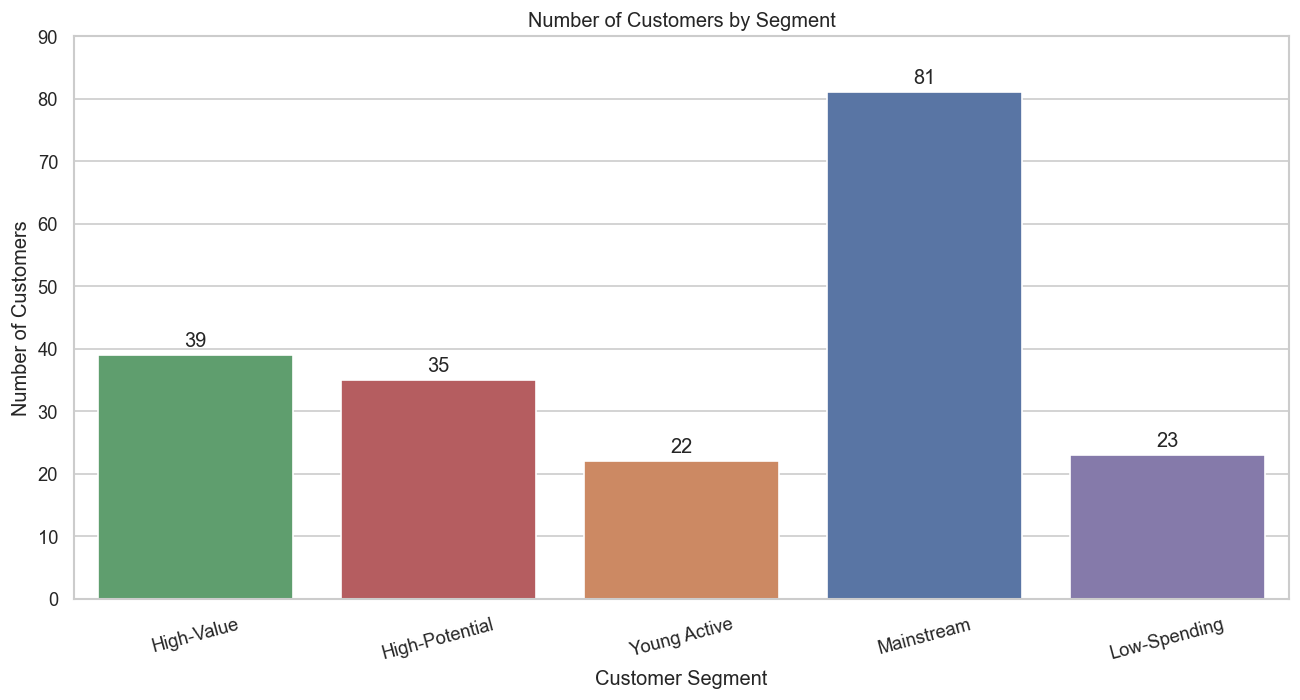

In [37]:
# 按业务顺序整理客群规模
segment_order = [
    'High-Value',
    'High-Potential',
    'Young Active',
    'Mainstream',
    'Low-Spending'
]

segment_size_plot = (
    df_clustered['segment_code']
    .value_counts()
    .reindex(segment_order)
    .rename_axis('segment_code')
    .reset_index(name='customer_count')
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segment_size_plot,
    x='segment_code',
    y='customer_count',
    hue='segment_code',
    palette=segment_colors,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.ylim(0, 90)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 10.3 客群规模结构

普通消费客群共81人，占40.50%，是规模最大的客户群，说明样本中的大部分客户具有中等收入和中等消费表现。

高价值客群和高潜力客群分别占19.50%和17.50%。两者合计占全部客户的37%，但消费表现明显不同：前者已经表现出较高消费活跃度，后者仍存在较大的消费转化空间。

年轻活跃客群和低消费客群分别占11.00%和11.50%，规模相对较小，适合采用更有针对性的运营策略，而不适合使用统一的大规模营销方式。

## 11. 聚类稳定性检验

一次聚类结果表现良好，并不代表模型在训练条件发生变化时仍然可靠。K-means可能受到初始聚类中心和样本变化的影响，因此本项目从两个方面检验聚类稳定性：

1. **随机种子稳定性检验**  
   使用10个不同随机种子重复训练模型，检查不同初始化条件是否改变客户划分。

2. **Bootstrap重抽样稳定性检验**  
   对原始客户进行100次有放回抽样，在每个Bootstrap样本上重新训练模型，再预测全部原始客户，检查样本变化是否改变整体客群结构。

不同聚类结果之间使用Adjusted Rand Index进行比较。ARI不受聚类编号顺序影响，数值越接近1，表示两次聚类的客户划分越一致。

In [38]:
# 使用最终模型标签作为基准
reference_labels = df_clustered['cluster'].values

random_seed_results = []

# 使用10个不同随机种子重复训练模型
for seed in range(10):
    seed_model = KMeans(
        n_clusters=optimal_k,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=seed
    )

    seed_labels = seed_model.fit_predict(X_scaled)

    ari_score = adjusted_rand_score(
        reference_labels,
        seed_labels
    )

    random_seed_results.append({
        'random_state': seed,
        'adjusted_rand_index': ari_score,
        'inertia': seed_model.inertia_
    })

seed_stability_df = pd.DataFrame(
    random_seed_results
)

display(
    seed_stability_df.style.format({
        'random_state': '{:.0f}',
        'adjusted_rand_index': '{:.4f}',
        'inertia': '{:.2f}'
    })
)

,random_state,adjusted_rand_index,inertia
0,0,1.0000,65.57
1,1,1.0000,65.57
2,2,1.0000,65.57
3,3,1.0000,65.57
4,4,1.0000,65.57
5,5,1.0000,65.57
6,6,1.0000,65.57
7,7,1.0000,65.57
8,8,1.0000,65.57
9,9,1.0000,65.57


In [39]:
# 汇总不同随机种子的稳定性结果
print(
    '平均 Adjusted Rand Index：'
    f'{seed_stability_df["adjusted_rand_index"].mean():.4f}'
)

print(
    '最低 Adjusted Rand Index：'
    f'{seed_stability_df["adjusted_rand_index"].min():.4f}'
)

print(
    'Inertia 标准差：'
    f'{seed_stability_df["inertia"].std():.6f}'
)

平均 Adjusted Rand Index：1.0000
最低 Adjusted Rand Index：1.0000
Inertia 标准差：0.000000


### 11.1 随机种子稳定性

使用10个不同随机种子重复训练模型后：

- 平均Adjusted Rand Index为1.0000；
- 最低Adjusted Rand Index为1.0000；
- Inertia的标准差为0。

这表明在使用K-means++初始化和50次初始中心搜索的条件下，不同随机种子得到的客户划分完全一致。模型没有因为随机初始化而产生不同的局部最优结果，具有良好的算法稳定性。

### 11.2 Bootstrap重抽样稳定性

随机种子检验主要检查模型初始化是否稳定，但不能反映训练样本发生变化时的结果波动。

因此，本项目进一步进行100次Bootstrap重抽样。每次从200位客户中有放回地抽取200条记录，并在重抽样数据上重新训练K=5模型。随后使用该模型预测全部原始客户，再将预测结果与基准模型进行比较。

In [40]:
# Bootstrap 重抽样稳定性检验
bootstrap_iterations = 100
bootstrap_rng = np.random.default_rng(RANDOM_STATE)

bootstrap_results = []

for iteration in range(bootstrap_iterations):
    # 有放回地抽取与原数据量相同的样本
    bootstrap_indices = bootstrap_rng.choice(
        len(X_scaled),
        size=len(X_scaled),
        replace=True
    )

    bootstrap_X = X_scaled[bootstrap_indices]

    bootstrap_model = KMeans(
        n_clusters=optimal_k,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=iteration
    )

    # 在 Bootstrap 样本上训练模型
    bootstrap_model.fit(bootstrap_X)

    # 使用重新训练的模型预测全部原始客户
    bootstrap_labels = bootstrap_model.predict(
        X_scaled
    )

    ari_score = adjusted_rand_score(
        reference_labels,
        bootstrap_labels
    )

    bootstrap_results.append({
        'iteration': iteration + 1,
        'adjusted_rand_index': ari_score
    })

bootstrap_stability_df = pd.DataFrame(
    bootstrap_results
)

display(
    bootstrap_stability_df.describe().style.format(
        '{:.4f}'
    )
)

,iteration,adjusted_rand_index
count,100.0000,100.0000
mean,50.5000,0.9732
std,29.0115,0.0226
min,1.0000,0.9142
25%,25.7500,0.9566
50%,50.5000,0.9732
75%,75.2500,0.9864
max,100.0000,1.0000


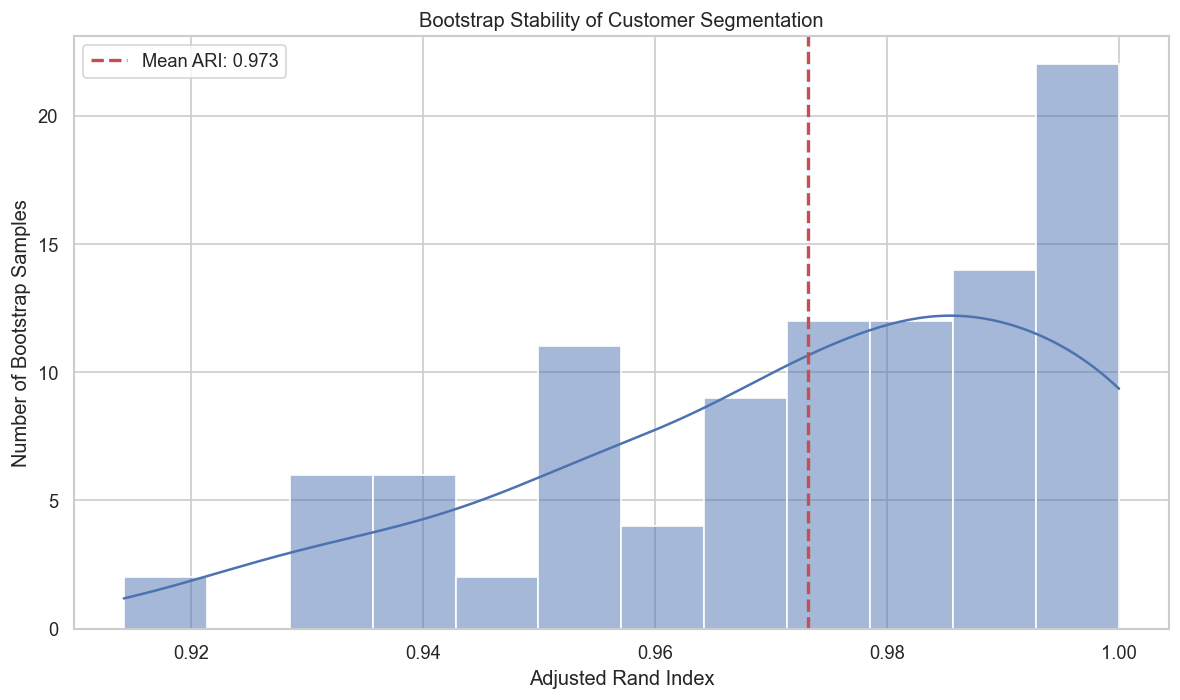

In [41]:
# 可视化 Bootstrap 稳定性结果
plt.figure(figsize=(10, 6))

sns.histplot(
    data=bootstrap_stability_df,
    x='adjusted_rand_index',
    bins=12,
    kde=True,
    color='#4C72B0',
    edgecolor='white'
)

plt.axvline(
    bootstrap_stability_df[
        'adjusted_rand_index'
    ].mean(),
    color='#C44E52',
    linestyle='--',
    linewidth=2,
    label=(
        'Mean ARI: '
        f'{bootstrap_stability_df["adjusted_rand_index"].mean():.3f}'
    )
)

plt.title(
    'Bootstrap Stability of Customer Segmentation'
)
plt.xlabel('Adjusted Rand Index')
plt.ylabel('Number of Bootstrap Samples')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# 汇总 Bootstrap 稳定性
bootstrap_mean_ari = bootstrap_stability_df[
    'adjusted_rand_index'
].mean()

bootstrap_min_ari = bootstrap_stability_df[
    'adjusted_rand_index'
].min()

high_stability_ratio = (
    bootstrap_stability_df[
        'adjusted_rand_index'
    ].ge(0.90).mean() * 100
)

print(f'Bootstrap平均ARI：{bootstrap_mean_ari:.4f}')
print(f'Bootstrap最低ARI：{bootstrap_min_ari:.4f}')
print(
    f'ARI不低于0.90的重复实验占比：'
    f'{high_stability_ratio:.2f}%'
)

Bootstrap平均ARI：0.9732
Bootstrap最低ARI：0.9142
ARI不低于0.90的重复实验占比：100.00%


### 11.3 稳定性检验结论

100次Bootstrap重抽样的结果显示：

| 稳定性指标 | 结果 |
|---|---:|
| 平均ARI | 0.9732 |
| 最低ARI | 0.9142 |
| ARI不低于0.90的实验占比 | 100% |

ARI分布整体集中在较高水平，平均值接近1。即使训练样本发生变化，模型仍然能够较稳定地恢复原有的五类客户结构。

结合随机种子检验和Bootstrap检验，可以认为当前K=5模型在本数据集上具有较高的聚类稳定性。不过，该结论主要反映模型在当前样本范围内的内部稳定性，不能替代使用新时期或新门店客户数据进行外部验证。

## 12. 客群特征对比

为了同时比较五类客户在年龄、年收入和消费得分上的相对水平，本项目将各客群的特征均值与全部客户的整体均值进行标准化比较。

热力图中的数值表示客群均值相对于整体客户均值的标准差距离：

- 正值表示该客群高于整体平均水平；
- 负值表示该客群低于整体平均水平；
- 数值绝对值越大，表示该客群与整体平均水平的差异越明显。

年龄没有直接参与聚类，此处加入年龄是为了补充解释聚类完成后的客群人口属性。

In [43]:
# 计算每个客群的原始特征均值
segment_feature_means = (
    df_clustered
    .groupby('segment_code')[[
        'age',
        'annual_income',
        'spending_score'
    ]]
    .mean()
    .reindex(segment_order)
)

# 使用全体客户均值和标准差进行标准化
overall_feature_mean = df_clustered[[
    'age',
    'annual_income',
    'spending_score'
]].mean()

overall_feature_std = df_clustered[[
    'age',
    'annual_income',
    'spending_score'
]].std(ddof=0)

segment_feature_scaled = (
    segment_feature_means - overall_feature_mean
) / overall_feature_std

display(
    segment_feature_scaled.style.format('{:.2f}')
)

,age,annual_income,spending_score
segment_code,,,
High-Value,-0.44,0.99,1.24
High-Potential,0.16,1.06,-1.28
Young Active,-0.97,-1.33,1.13
Mainstream,0.28,-0.20,-0.03
Low-Spending,0.46,-1.31,-1.14


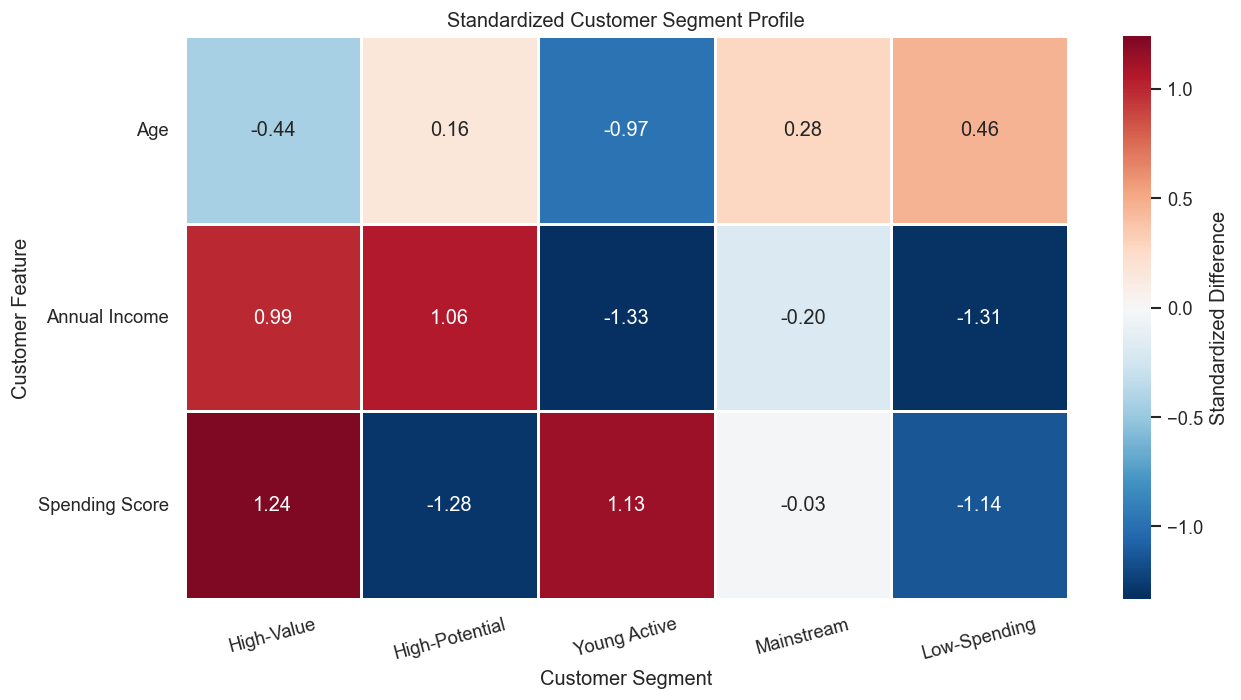

In [44]:
# 绘制标准化客群画像热力图
plt.figure(figsize=(11, 6))

sns.heatmap(
    segment_feature_scaled.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.8,
    cbar_kws={
        'label': 'Standardized Difference'
    }
)

plt.title('Standardized Customer Segment Profile')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Feature')
plt.xticks(rotation=15)
plt.yticks(
    ticks=[0.5, 1.5, 2.5],
    labels=[
        'Age',
        'Annual Income',
        'Spending Score'
    ],
    rotation=0
)
plt.tight_layout()
plt.show()

### 12.1 客群特征热力图分析

热力图进一步显示了五类客户的差异：

- **高价值客群**：年收入高于整体平均水平0.99个标准差，消费得分高出1.24个标准差，同时平均年龄低于整体水平；
- **高潜力客群**：年收入高出整体平均水平1.06个标准差，但消费得分低于整体水平1.28个标准差，呈现出明显的高能力、低活跃特征；
- **年轻活跃客群**：平均年龄低于整体水平0.97个标准差，年收入低于整体水平1.33个标准差，但消费得分高出1.13个标准差；
- **普通消费客群**：三个特征均较接近整体平均水平，其中消费得分与整体均值几乎一致；
- **低消费客群**：平均年龄相对较高，年收入和消费得分分别低于整体水平1.31和1.14个标准差。

热力图与聚类中心、散点图和客户画像表的结论保持一致，说明五类客群具有较清晰的特征差异和业务解释。

## 13. 差异化客户运营策略

客户细分的最终目的不是简单地为客户添加标签，而是根据不同客群的消费能力、消费表现和潜在价值配置营销资源。

本项目从客群特征、运营优先级、推荐策略和运营目标四个方面制定差异化建议。相关建议属于基于客户画像提出的业务假设，实际实施前仍需要结合商品偏好、历史交易数据和营销A/B测试进行验证。

In [45]:
# 构建不同客群的运营策略
operation_strategy = pd.DataFrame({
    'customer_segment': [
        '高价值客群',
        '高潜力客群',
        '年轻活跃客群',
        '普通消费客群',
        '低消费客群'
    ],
    'customer_characteristics': [
        '高收入、高消费，是当前价值最高的客户',
        '高收入、低消费，消费能力尚未充分转化',
        '年龄较低、收入较低，但消费活跃度较高',
        '收入和消费表现均处于中等水平，客户规模最大',
        '收入和消费活跃度均较低，当前价值有限'
    ],
    'operation_priority': [
        '最高',
        '高',
        '中高',
        '中',
        '低'
    ],
    'recommended_strategy': [
        'VIP分层维护、专属权益、新品优先购、会员保级',
        '个性化推荐、高门槛优惠券、专属体验和消费唤醒',
        '社交传播、积分裂变、限时折扣和年轻化商品推荐',
        '会员积分、组合促销、满减活动和交叉销售',
        '低成本自动化触达、基础优惠和流失监测'
    ],
    'primary_goal': [
        '提高留存率和客户生命周期价值',
        '将消费能力转化为实际消费',
        '维持活跃度并培养长期价值',
        '提高购买频率和客单价',
        '控制营销成本并识别可挽回客户'
    ]
})

display(operation_strategy)

,customer_segment,customer_characteristics,operation_priority,recommended_strategy,primary_goal
0,高价值客群,高收入、高消费，是当前价值最高的客户,最高,VIP分层维护、专属权益、新品优先购、会员保级,提高留存率和客户生命周期价值
1,高潜力客群,高收入、低消费，消费能力尚未充分转化,高,个性化推荐、高门槛优惠券、专属体验和消费唤醒,将消费能力转化为实际消费
2,年轻活跃客群,年龄较低、收入较低，但消费活跃度较高,中高,社交传播、积分裂变、限时折扣和年轻化商品推荐,维持活跃度并培养长期价值
3,普通消费客群,收入和消费表现均处于中等水平，客户规模最大,中,会员积分、组合促销、满减活动和交叉销售,提高购买频率和客单价
4,低消费客群,收入和消费活跃度均较低，当前价值有限,低,低成本自动化触达、基础优惠和流失监测,控制营销成本并识别可挽回客户


### 13.1 各客群运营建议

#### 高价值客群：重点维护

该客群同时具有高收入和高消费特征，应设置为最高运营优先级。商场可以提供VIP会员等级、专属客服、新品优先购、会员保级和定制化权益。

由于这些客户已经表现出较高消费活跃度，运营目标应以提高留存率和客户生命周期价值为主，而不是频繁提供无差别价格折扣。

#### 高潜力客群：重点转化

该客群具有较强消费能力，但当前消费得分较低，是最值得开展精准营销的潜力客户。可以通过个性化商品推荐、高门槛优惠券、专属体验和定向唤醒活动促进消费能力向实际购买行为转化。

在采取营销措施前，还应进一步分析其低消费原因，例如商品匹配不足、渠道偏好差异或客户体验问题。

#### 年轻活跃客群：培养长期价值

该客群收入水平相对较低，但年龄较轻、消费意愿和活跃度较强。适合采用社交传播、积分裂变、限时活动、年轻化商品推荐和互动式会员机制。

运营重点应放在维持活跃度、提高客户黏性，并随着其收入水平和消费能力提升逐步培养长期价值。

#### 普通消费客群：提升频率与客单价

该客群规模最大，是商场稳定收入的重要来源。可以通过会员积分、满减活动、组合促销和交叉销售提高购买频率与客单价。

由于该客群内部可能仍存在差异，未来可以结合商品品类和交易频率进行进一步细分。

#### 低消费客群：控制投入

该客群当前收入和消费活跃度均较低，不适合投入过高的人工营销成本。可采用短信、邮件、App推送等自动化方式进行低成本触达，并监测其中是否存在可以恢复活跃的客户。

运营重点应在控制营销成本的同时，识别潜在流失客户和可挽回客户。

## 14. 结果导出与完整性检查

为了支持后续客户运营和结果复用，本项目输出三类分析结果：

1. **客户标签明细表**  
   包含每位客户的基础信息、聚类编号、中文客群名称和英文客群名称。

2. **客群画像汇总表**  
   包含各客群的客户数量、客户占比、平均年龄、平均收入、平均消费得分和性别构成。

3. **客群运营策略表**  
   包含不同客群的核心特征、运营优先级、推荐策略和主要运营目标。

In [46]:
# 整理最终客户标签结果
customer_segmentation_result = df_clustered[[
    'customer_id',
    'gender',
    'age',
    'annual_income',
    'spending_score',
    'cluster',
    'segment_name',
    'segment_code'
]].copy()

display(customer_segmentation_result.head())

,customer_id,gender,age,annual_income,spending_score,cluster,segment_name,segment_code
0,1,Male,19,15,39,4,低消费客群,Low-Spending
1,2,Male,21,15,81,2,年轻活跃客群,Young Active
2,3,Female,20,16,6,4,低消费客群,Low-Spending
3,4,Female,23,16,77,2,年轻活跃客群,Young Active
4,5,Female,31,17,40,4,低消费客群,Low-Spending


In [47]:
# 检查最终客户标签
print(
    '客群名称缺失数量：',
    customer_segmentation_result[
        'segment_name'
    ].isnull().sum()
)

print(
    '最终客户记录数量：',
    len(customer_segmentation_result)
)

print(
    '唯一客户编号数量：',
    customer_segmentation_result[
        'customer_id'
    ].nunique()
)

客群名称缺失数量： 0
最终客户记录数量： 200
唯一客户编号数量： 200


In [48]:
# 导出每位客户的聚类标签
customer_segmentation_result.to_csv(
    'customer_segmentation_results.csv',
    index=False,
    encoding='utf-8-sig'
)

# 导出客群画像汇总表
segment_profile.to_csv(
    'customer_segment_profiles.csv',
    index=False,
    encoding='utf-8-sig',
    float_format='%.2f'
)

# 导出客群运营策略表
operation_strategy.to_csv(
    'customer_operation_strategies.csv',
    index=False,
    encoding='utf-8-sig'
)

print('结果文件导出完成：')
print('1. customer_segmentation_results.csv')
print('2. customer_segment_profiles.csv')
print('3. customer_operation_strategies.csv')

结果文件导出完成：
1. customer_segmentation_results.csv
2. customer_segment_profiles.csv
3. customer_operation_strategies.csv


In [49]:
# 项目最终完整性检查
final_check = {
    '原始记录数': len(df),
    '清洗后记录数': len(df_clean),
    '聚类后记录数': len(df_clustered),
    '唯一客户数': df_clustered['customer_id'].nunique(),
    '客群数量': df_clustered['cluster'].nunique(),
    '客群名称缺失数': df_clustered['segment_name'].isnull().sum(),
    '最佳K值': optimal_k,
    '轮廓系数': silhouette_score(
        X_scaled,
        df_clustered['cluster']
    ),
    'Davies-Bouldin Score': davies_bouldin_score(
        X_scaled,
        df_clustered['cluster']
    ),
    'Bootstrap平均ARI': bootstrap_mean_ari
}

final_check_df = pd.DataFrame(
    final_check.items(),
    columns=['检查项目', '结果']
)

display(
    final_check_df.style.format({
        '结果': lambda x: (
            f'{x:.4f}'
            if isinstance(x, float)
            else str(x)
        )
    })
)

,检查项目,结果
0,原始记录数,200.0000
1,清洗后记录数,200.0000
2,聚类后记录数,200.0000
3,唯一客户数,200.0000
4,客群数量,5.0000
5,客群名称缺失数,0.0000
6,最佳K值,5.0000
7,轮廓系数,0.5547
8,Davies-Bouldin Score,0.5722
9,Bootstrap平均ARI,0.9732


### 14.1 最终完整性检查

最终检查结果确认：

- 原始、清洗后和聚类后的数据均为200条；
- 客户编号的唯一值数量为200；
- 最终成功划分为5个客户群；
- 所有客户均获得有效的客群名称，不存在标签缺失；
- 最终模型轮廓系数约为0.5547；
- Davies-Bouldin Score约为0.5722；
- Bootstrap平均ARI约为0.9732。

数据处理、模型训练、客户标签映射、模型评价和结果导出之间保持一致，分析流程完整。

## 15. 项目结论

本项目基于200条商场客户记录，使用年收入和消费得分作为核心特征建立K-means客户细分模型。

通过数据质量检查，确认数据不存在缺失值、重复记录或违反业务规则的无效值，并保留了两条具有合理业务意义的高收入客户记录。探索性分析发现，年收入与消费得分虽然整体线性相关性较弱，但在二维空间中呈现出清晰的局部群体结构。

在模型选择阶段，综合Inertia、Silhouette Score、Calinski-Harabasz Score、Davies-Bouldin Score以及业务可解释性，最终选择K=5。模型将客户划分为：

- 普通消费客群：81人，占40.50%；
- 高价值客群：39人，占19.50%；
- 年轻活跃客群：22人，占11.00%；
- 高潜力客群：35人，占17.50%；
- 低消费客群：23人，占11.50%。

模型的轮廓系数约为0.5547，Davies-Bouldin Score约为0.5722。10组随机种子得到完全一致的客户划分，100次Bootstrap重抽样的平均ARI约为0.9732，说明五类客户结构在当前样本中具有较好的分离程度和稳定性。

从业务角度看，高价值客群应以留存和生命周期价值提升为重点；高潜力客群应作为精准营销和消费转化的重点对象；年轻活跃客群适合进行长期价值培养；普通消费客群应通过会员运营提升购买频率与客单价；低消费客群则应采用低成本自动化运营方式。

该分析将客户数据转化为可解释的客户标签和差异化运营建议，为会员分层、营销资源配置和客户精细化运营提供了数据支持。

## 16. 项目局限

尽管本项目获得了清晰且较为稳定的客户细分结果，但仍存在以下局限：

1. **样本规模较小**  
   数据集仅包含200位客户，可能无法完整代表不同地区、门店和消费场景中的全部客户群体。

2. **客户特征有限**  
   数据仅包含年龄、性别、年收入和消费得分，缺少购买频率、订单金额、最近消费时间、商品品类、会员等级和营销响应等重要变量。

3. **消费得分定义不透明**  
   `spending_score` 是数据集提供的综合指标，但缺少具体计算方式，因此无法进一步解释哪些行为推动了消费得分变化。

4. **缺少时间维度**  
   当前数据属于静态客户快照，无法分析客户生命周期、季节变化、流失趋势和客群迁移。

5. **聚类属于描述性分析**  
   K-means可以识别特征相似的客户，但不能证明运营策略会导致消费提升。项目提出的策略仍需通过营销实验验证。

6. **模型存在方法假设**  
   K-means主要基于欧氏距离，更适合识别形状相对规则的客户群体，对异常值和复杂形状的聚类结构可能较为敏感。

7. **缺少外部验证**  
   当前稳定性检验基于同一数据集的随机初始化和Bootstrap重抽样，尚未使用新时期、新门店或独立客户数据验证模型的泛化能力。

8. **人口属性存在局限**  
   原始数据中的性别字段只包含两个类别，无法完整反映现实客户群体的多样性。相关变量应谨慎用于客户运营，避免形成不合理的差异化待遇。